In [ ]:
### Please check _common.py for common paths and loaded packages 
from _common import *

### Automatic reloading of modules
%load_ext autoreload
%autoreload 2

%matplotlib inline

## Read station info

In [2]:
# Projections
proj = ccrs.PlateCarree(central_longitude=-90)
proj_data = ccrs.PlateCarree()

# Earth distance
geod = Geod(ellps='WGS84')


### Hurricane track ###
# Hurricane information: 2012 Isaac
tc_info = tc_func.get_tc_info(year=2012, name='Isaac', agency='USA')

# Interpolation function for TC track
f_loc, t0 = tc_func.get_interp_func(tc_info)


### Seismic station ###
# Read seismic station list
sta_info = pd.read_csv(os.path.join(data_dir, 'TA/TA_list.csv'))

# Specific seismic station
seis_sta_loc = np.array([get_sta_loc(['TA', '645A'], sta_info)])[0]


### ASOS station ###
# Read ASOS station metadata
csv_files = [os.path.join(data_dir, 'ASOS/LA_meta.csv')]

start_date = pd.to_datetime('2012-08-01')
end_date = pd.to_datetime('2012-10-01')
asos_info = read_asos_metadata(csv_files, start_date, end_date)

# Specific ASOS station
asos_sta_loc = np.array([get_asos_sta_loc('HUM', asos_info)])[0]

## Read atmospheric data

In [3]:
### Read hurricane center from radar images ###

ctl_file = os.path.join(data_dir, 'Isaac/radar', '20120828H2_radar.ctl')
ctl = CtlDescriptor(file=ctl_file)
dset = open_CtlDataset(ctl_file)

# Estimate hurricane center
levels = [1, 2, 3, 4]
center_lons, center_lats = [], []

for ilevel in levels:
    
    # Calculate wind speed
    u, v = dset.u[0,ilevel], dset.v[0,ilevel]
    u, v = u.where(u!=ctl.undef), v.where(v!=ctl.undef)
    wspd = np.sqrt(u**2 + v**2)

    # Lowest percentage
    center_mask = xr.where(wspd < np.nanpercentile(wspd.values, 5), 1, 0)
    center_N = center_mask.sum().values
    center_lons.append(xr.dot(center_mask, wspd.lon).sum().values / center_N)
    center_lats.append(xr.dot(center_mask, wspd.lat).sum().values / center_N)

# Hurricane center estimated from radar images
t_radar = pd.to_datetime(wspd.time.values)
center_lon, center_lat = np.mean(center_lons), np.mean(center_lats)
print(f'Hurricane center: Lon {center_lon:.4f}, Lat {center_lat:.4f}')

del u, v, wspd, center_mask, center_N, center_lons, center_lats

Hurricane center: Lon -89.7758, Lat 28.8446


In [4]:
### Select dropsonde data ###

# Calculate distance from hurricane center (IBTrACS)
def _calc_dist(df):
    _, tc_lon, tc_lat = tc_func.interp_track(f_loc, t0, time_list=[df['ref_time']])
    dist = tc_func.get_station_dist([df['ref_lon'], df['ref_lat']], np.array([[tc_lon], [tc_lat]]))
    return np.squeeze(dist)

# Read dropsonde info
nc_df = read_dropsonde_metadata()
nc_df.insert(1, 'raw_dist', nc_df.apply(_calc_dist, axis=1))
nc_df = nc_df.sort_values(by='ref_time')
nc_df = nc_df.reset_index(drop=True)

# Time range
dt_radar = pd.Timedelta(hours=0.5)
mask = (nc_df['ref_time'] >= t_radar-dt_radar) & (nc_df['ref_time'] <= t_radar+dt_radar)
nc_df_radar = nc_df[mask]

# Update distance from radar-based hurricane center
def _calc_dist(df):
    dist = tc_func.get_station_dist([df['ref_lon'], df['ref_lat']], np.array([[center_lon], [center_lat]]))
    return np.squeeze(dist)

# Sort distance
nc_df_radar.insert(1, 'new_dist', nc_df_radar.apply(_calc_dist, axis=1))
nc_df_radar = nc_df_radar.sort_values(by='new_dist')
nc_df_radar = nc_df_radar.reset_index(drop=True)

In [5]:
### ERA5 reanalysis data ###
era5_dir = os.path.join(data_dir, 'Isaac/ERA5')
t1, t2 = '2012-08-28T23:30:00', '2012-08-29T00:30:00'

# Read ERA5 data: Single level
era5_file = os.path.join(era5_dir, 'data_stream-oper.nc')
era5_slev_data = atm_ds.read_era5(era5_file, ts=t1, te=t2)

# Read ERA5 data: Pressure levels
era5_file = os.path.join(era5_dir, 'data_pres_level.nc')
era5_plev_data = atm_ds.read_era5(era5_file, ts=t1, te=t2)

### Radiosonde ###
rs_file = os.path.join(data_dir, 'Isaac/radiosonde/2012082900-72233.csv')
rs_profile = atm_ds.read_radiosonde(rs_file)

### NEXRAD VAD Profile ###
vad_data = xr.open_dataset(os.path.join(data_dir, 'Isaac/NEXRAD/KLIX_VAD.nc'))
vad_data = vad_data.sel(time=slice(t1, t2))
nexrad_sta_loc = (vad_data.longitude, vad_data.latitude)

ERA5: Single level
ERA5: Pressure level


## Radar wind plots

In [6]:
### Radial wind profile ####

# Select height level
ilevel = 2
u, v = dset.u[0,ilevel], dset.v[0,ilevel]
u, v = u.where(u!=ctl.undef), v.where(v!=ctl.undef)
wspd = np.sqrt(u**2 + v**2)

# Valid grid points
mask = ~np.isnan(wspd)
radar_lon, radar_lat = np.meshgrid(wspd.lon, wspd.lat)
radar_lon, radar_lat = radar_lon[mask], radar_lat[mask]
radar_u, radar_v, radar_wspd = u.values[mask], v.values[mask], wspd.values[mask]

# Number of grid points
Npts = len(radar_wspd)

# Polar coordinate (w.r.t. TC center)
radar_az, _, radar_dist = geod.inv([center_lon]*Npts, [center_lat]*Npts, radar_lon, radar_lat)
az_rad = np.deg2rad(radar_az)

# Radial & Tangential wind
radar_Vr = radar_u * np.sin(az_rad) + radar_v * np.cos(az_rad)
radar_Vt = -radar_u * np.cos(az_rad) + radar_v * np.sin(az_rad)

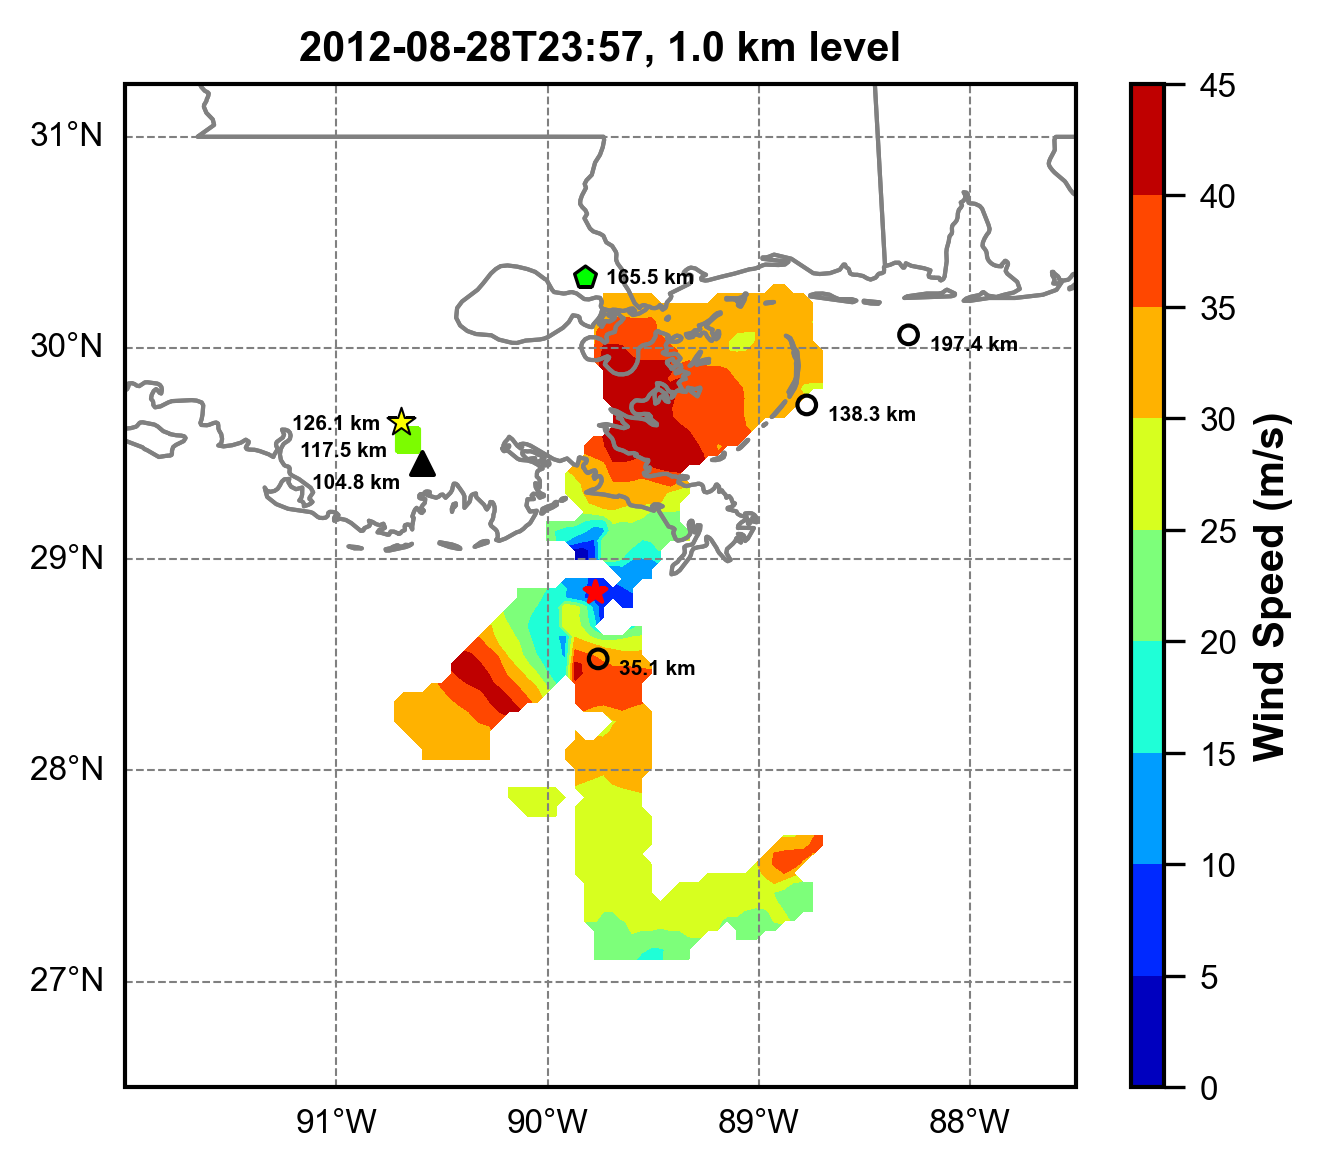

In [7]:
figsize = (5, 4)
label_fontsize = 10
tick_fontsize = 8
title_fontsize = 10
marker_size = 30

### Plot radar wind ###
extent = [-92, -87.5, 26.5, 31.25]
fig, ax = plt.subplots(figsize=figsize, subplot_kw={'projection': proj})
ax.set_extent(extent, crs=proj_data)
ax.add_feature(cfeature.STATES, edgecolor='gray')
ax.add_feature(cfeature.COASTLINE, edgecolor='gray')

obj = ax.contourf(wspd.lon, wspd.lat, wspd,
                  transform=proj_data, cmap='jet',
                  levels=np.arange(0, 50, 5))

ax.set_title(f"{np.datetime64(wspd.time.values,'m')}, "
             f"{wspd.lev.values/1e3:.1f} km level", fontsize=title_fontsize)
fig.colorbar(obj, ax=ax, pad=0.04, label='Wind Speed (m/s)', aspect=30)

# Gridlines
gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linestyle='--')
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': tick_fontsize}
gl.ylabel_style = {'size': tick_fontsize}

# TC location from archive track
t_radar = pd.to_datetime(wspd.time.values)
_, tc_lon, tc_lat = tc_func.interp_track(f_loc, t0, time_list=[UTCDateTime(t_radar+pd.Timedelta(hours=0))])

# Station locations
seis_sta_loc = np.array(get_sta_loc(['TA', '645A'], sta_info))
asos_sta_loc = np.array(get_asos_sta_loc('HUM', asos_info))
_, seis_az, seis_sta_dist = geod.inv(center_lon, center_lat, seis_sta_loc[0], seis_sta_loc[1])
_, asos_az, asos_sta_dist = geod.inv(center_lon, center_lat, asos_sta_loc[0], asos_sta_loc[1])
_, rs_az, rs_sta_dist = geod.inv(center_lon, center_lat, rs_sta_loc[0], rs_sta_loc[1])
_, tower_az, tower_dist = geod.inv(center_lon, center_lat, tower_loc[0], tower_loc[1])
_, vad_az, vad_dist = geod.inv(center_lon, center_lat, nexrad_sta_loc[0], nexrad_sta_loc[1])

asos_sta_loc2 = np.array(get_asos_sta_loc('ASD', asos_info))
_, asos_az2, asos_sta_dist2 = geod.inv(center_lon, center_lat, asos_sta_loc2[0], asos_sta_loc2[1])

# Plot zero_wind hurricane center
ax.scatter(center_lon, center_lat, s=30, c='r', marker='*', transform=proj_data)

# Plot station
ax.scatter(seis_sta_loc[0], seis_sta_loc[1], s=30, c='k', marker='^', transform=proj_data, zorder=10)
ax.scatter(asos_sta_loc[0], asos_sta_loc[1], s=30, c='lawngreen', marker='s', transform=proj_data)
# ax.scatter(asos_sta_loc2[0], asos_sta_loc2[1], s=30, c='lawngreen', marker='s', transform=proj_data)
ax.scatter(rs_sta_loc[0], rs_sta_loc[1], s=30, c='lime', marker='p', edgecolor='k', lw=0.8, transform=proj_data)
ax.scatter(tower_loc[0], tower_loc[1], s=50, c='yellow', marker='*', edgecolor='k', lw=0.5, transform=proj_data)

# Annotate station distance
ax.text(seis_sta_loc[0]-0.1, seis_sta_loc[1]-0.05, f'{seis_sta_dist/1e3:.1f} km', transform=proj_data, 
        color='k', horizontalalignment='right', verticalalignment='top', fontsize=5, fontweight='bold')
ax.text(asos_sta_loc[0]-0.1, asos_sta_loc[1]-0.05, f'{asos_sta_dist/1e3:.1f} km', transform=proj_data, 
        color='k', horizontalalignment='right', verticalalignment='center', fontsize=5, fontweight='bold')
# ax.text(asos_sta_loc2[0]-0.1, asos_sta_loc2[1]-0.05, f'{asos_sta_dist2/1e3:.1f} km', transform=proj_data, 
#         color='k', horizontalalignment='right', verticalalignment='center', fontsize=5, fontweight='bold')
ax.text(rs_sta_loc[0]+0.1, rs_sta_loc[1]-0.05, f'{rs_sta_dist/1e3:.1f} km', transform=proj_data, 
        color='k', horizontalalignment='left', verticalalignment='bottom', fontsize=5, fontweight='bold')
ax.text(tower_loc[0]-0.1, tower_loc[1]-0.05, f'{tower_dist/1e3:.1f} km', transform=proj_data, 
        color='k', horizontalalignment='right', verticalalignment='bottom', fontsize=5, fontweight='bold')

# Plot dropsonde location
ds_loc = []
for ds_ in nc_df_radar.itertuples(index=False):
    if ds_.new_dist < 33:
        continue
    
    ds_loc.append([ds_.ref_lon, ds_.ref_lat])
    ax.scatter(ds_.ref_lon, ds_.ref_lat, s=20, facecolors='none', edgecolors='k', transform=proj_data)
    ax.text(ds_.ref_lon+0.1, ds_.ref_lat, f'{ds_.new_dist:.1f} km', transform=proj_data, 
            color='k', horizontalalignment='left', verticalalignment='top', fontsize=5, fontweight='bold')
ds_loc = np.array(ds_loc)

plt.tight_layout()
# fig.savefig(os.path.join(sup_dir, 'radar.pdf'), dpi=400, bbox_inches='tight', pad_inches=0)


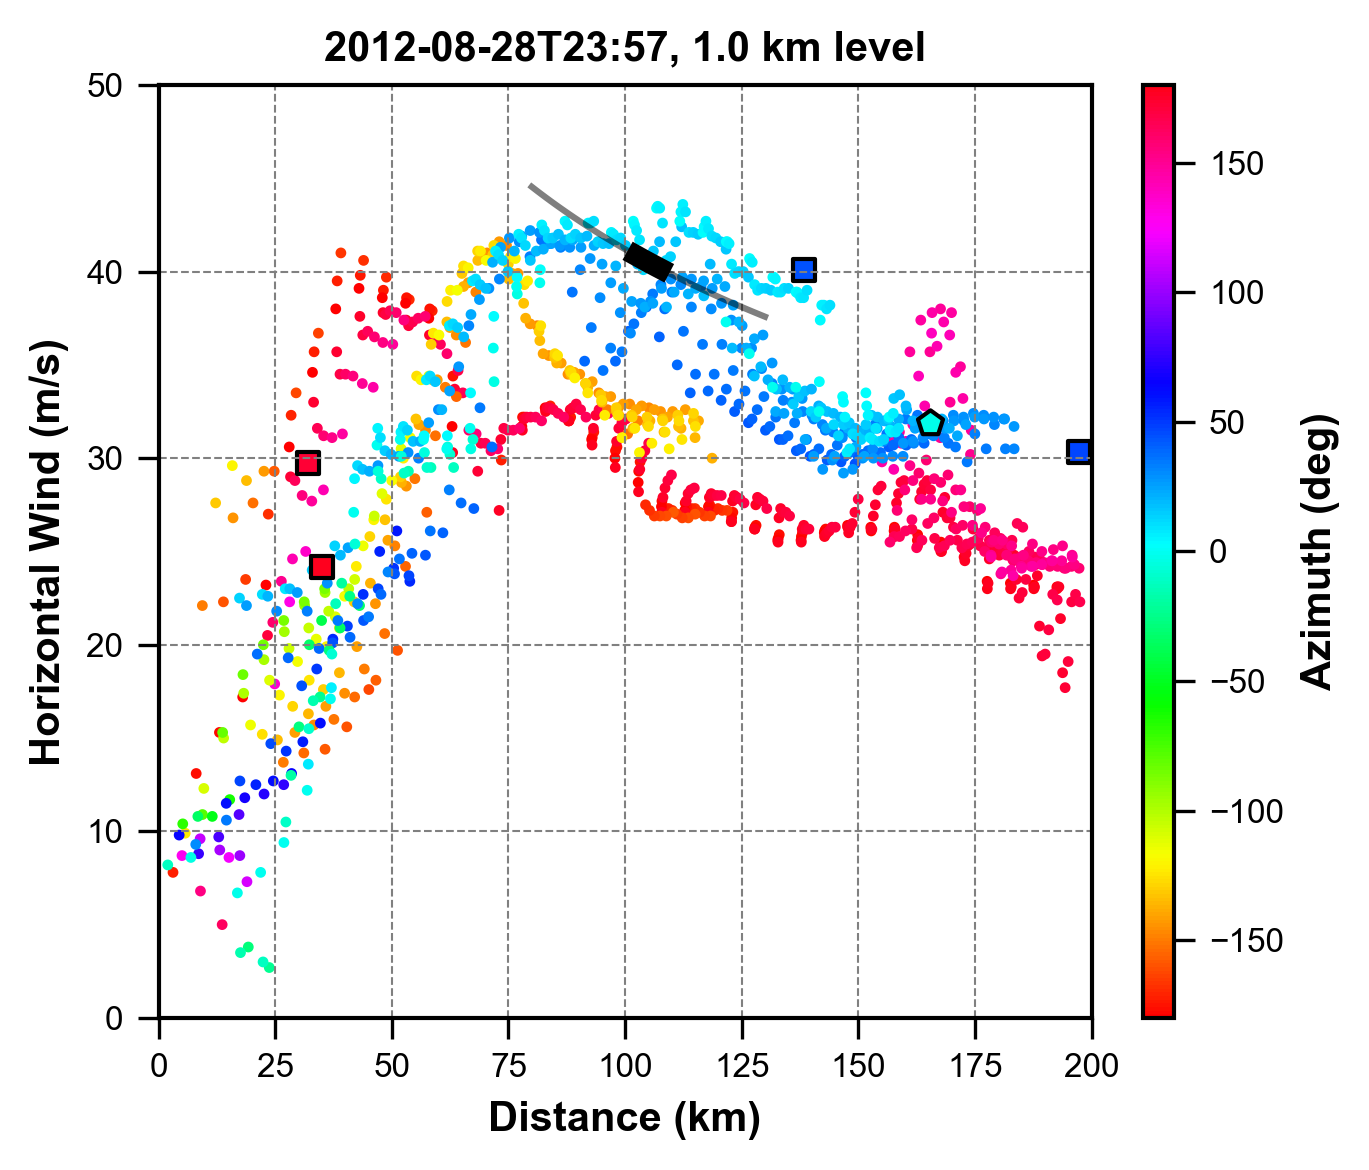

In [8]:
# Plot radial wind profile
fig, ax = plt.subplots(figsize=figsize)

sc = ax.scatter(radar_dist/1e3, radar_wspd, s=10, marker='.',
                c=radar_az, cmap='hsv', vmin=-180, vmax=180)

ax.set_xlabel('Distance (km)', fontsize=label_fontsize)
ax.set_ylabel('Horizontal Wind (m/s)', fontsize=label_fontsize)
ax.tick_params(axis='both', labelsize=tick_fontsize)
ax.set_title(f"{np.datetime64(wspd.time.values,'m')}, "
             f"{wspd.lev.values/1e3:.1f} km level", fontsize=title_fontsize)
ax.set_xlim([0, 200])
ax.set_ylim([0, 50])
ax.grid(True)

cbar = fig.colorbar(sc, ax=ax, pad=0.04, aspect=30)
cbar.set_label('Azimuth (deg)', fontsize=label_fontsize)

# Power laws
V_, R_ = 40.5, 105
n_ = 0.35
r_ = np.linspace(105-2.5, 105+2.5, 50)
S_ = V_ * (R_/r_)**n_
ax.plot(r_, S_, 'k-', lw=5, label=f'n = {n_}')
r_ = np.linspace(105-25, 105+25, 50)
S_ = V_ * (R_/r_)**n_
ax.plot(r_, S_, 'k-', lw=1.5, alpha=0.5, label=f'n = {n_}')

# Dropsonde data
for ds_ in nc_df_radar.itertuples(index=False):
    ds_data = nc.Dataset(ds_.filename, 'r')
    lev_mask = np.abs(ds_data.variables['alt'][:]-wspd.lev.values) < 100
    if lev_mask.sum() == 0:
        continue
    lev_wspd = np.mean(ds_data.variables['wspd'][:][lev_mask])
    lev_az, _, _ = geod.inv(center_lon, center_lat, ds_.ref_lon, ds_.ref_lat)
    ax.scatter(ds_.new_dist, lev_wspd, s=30, marker='s', c=lev_az, cmap='hsv', vmin=-180, vmax=180, edgecolor='k')

# Radiosonde data
lev_mask = np.abs(rs_profile['z']-wspd.lev.values) < 100
if lev_mask.sum() != 0:
    lev_wspd = np.mean(rs_profile['wspd'][lev_mask])
    lev_az, _, _ = geod.inv(center_lon, center_lat, rs_sta_loc[0], rs_sta_loc[1])
    ax.scatter(rs_sta_dist/1e3, lev_wspd, s=40, marker='p', c=lev_az, cmap='hsv', vmin=-180, vmax=180, edgecolor='k')

ax.set_aspect(4)
plt.tight_layout()
# fig.savefig(os.path.join(sup_dir, 'wind_radial_profile.pdf'), dpi=400, bbox_inches='tight', pad_inches=0)


## Vertical profiles

In [9]:
### Read CM1 output ###
cm1_R = 105

# Read CM1 profiles
les_dir = os.path.join(data_dir, 'CM1/outputs')
les_data = loadmat(os.path.join(les_dir, 'diag_profile_6.mat'))
les_profile = {'zh': np.squeeze(les_data['scalar_struct']['zh'][0][0]), 
               'u': np.squeeze(les_data['scalar_struct']['u'][0][0]), 
               'v': np.squeeze(les_data['scalar_struct']['v'][0][0]),
               'wsp': np.squeeze(les_data['scalar_struct']['wsp'][0][0]),
               'theta': np.squeeze(les_data['scalar_struct']['th'][0][0]),
               'qv':np.squeeze(les_data['scalar_struct']['qv'][0][0]) * 1e3}

In [10]:
### Select ASOS data ###
asos_data, _ = tc_func.read_ASOS_data(os.path.join(data_dir, 'ASOS/645A_HUM.csv'))

# Select time range
dt_asos = pd.Timedelta(hours=1)
t_radar = pd.Timestamp('2012-08-29 00:00:00')
_tmask = ((asos_data['time'] >= t_radar-dt_asos) & (asos_data['time'] <= t_radar+dt_asos))
asos_val = asos_data[_tmask].iloc[0]

### Select specific dropsonde location ###
ids = 2
df_avp = cm1_func.clean_avp(nc.Dataset(nc_df_radar.iloc[ids].filename, 'r'))
ds_loc = [nc_df_radar.iloc[ids].ref_lon, nc_df_radar.iloc[ids].ref_lat]
ds_dist = nc_df_radar.iloc[ids].new_dist

### ERA5 Reanalysis: Interpolation ###
era5_slev_seis = era5_slev_data.interp(latitude=seis_sta_loc[1], longitude=seis_sta_loc[0]).mean(dim='valid_time')
era5_plev_seis = era5_plev_data.interp(latitude=seis_sta_loc[1], longitude=seis_sta_loc[0]).mean(dim='valid_time')

era5_plev_radio = era5_plev_data.interp(latitude=rs_sta_loc[1], longitude=rs_sta_loc[0]).mean(dim='valid_time')

In [11]:
### NEXRAD VAD profile ###
vad_alt = vad_data["alt"].values
vad_z = np.unique(vad_alt[np.isfinite(vad_alt)])
vad_wspd = np.sqrt(vad_data['u'].values**2 + vad_data["v"].values**2)

vad_mean = np.full(vad_z.shape, np.nan)
vad_std  = np.full(vad_z.shape, np.nan)
for i, zi in enumerate(vad_z):
    mask = (vad_alt == zi) & np.isfinite(vad_wspd)
    if np.any(mask):
        vad_mean[i] = np.nanmean(vad_wspd[mask])
        vad_std[i]  = np.nanstd(vad_wspd[mask])

vad_profile = {'z': vad_z, 'wspd_mean': vad_mean, 'wspd_std': vad_std}

ASOS wind: 13.88 m/s


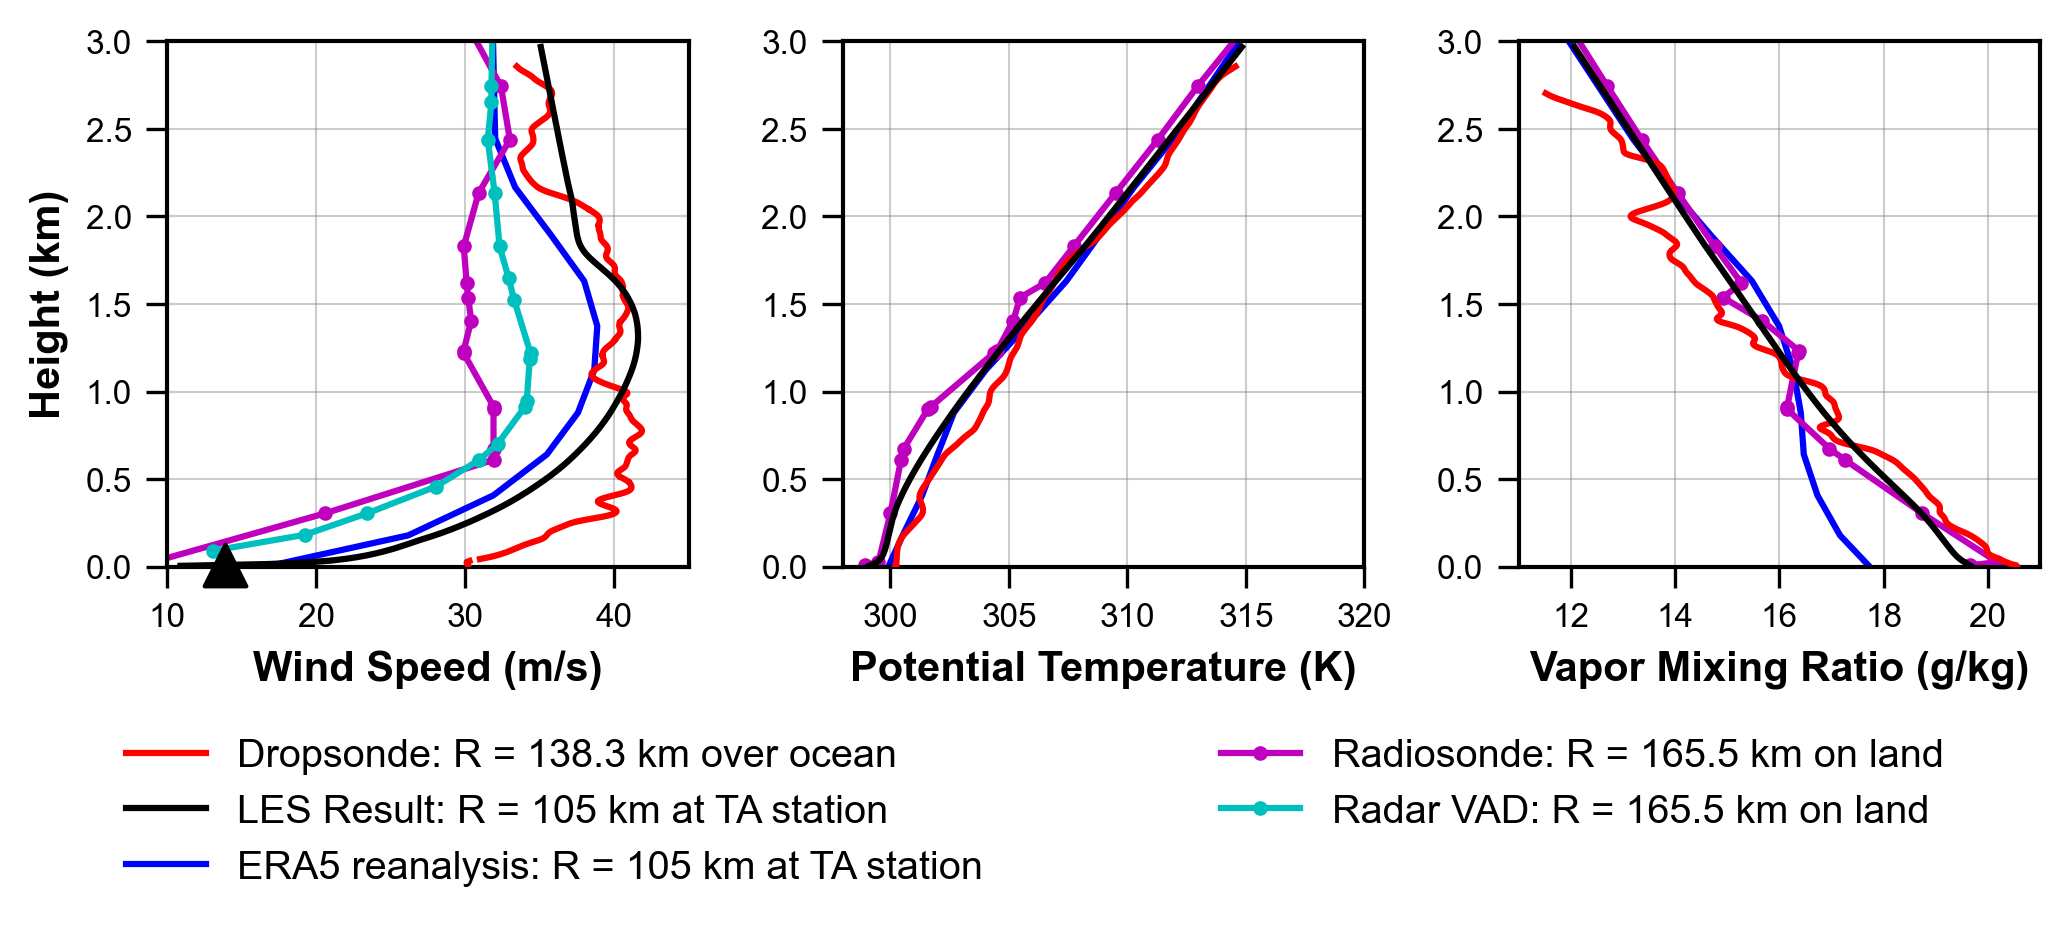

In [12]:
# Plot sounding profiles
fig, axes = plt.subplots(1, 3, figsize=(7,2.5))
lw = 1.5

# Dropsonde profiles
zorder = 3
label = f'Dropsonde: R = {ds_dist:.1f} km over ocean'
axes[0].plot(df_avp['wspd (m/s)'][:], df_avp['z (m)'][:]/1e3, 'r-', lw=lw, label=label, zorder=zorder)
axes[1].plot(df_avp['theta (K)'][:],  df_avp['z (m)'][:]/1e3, 'r-', lw=lw, label=label, zorder=zorder)
axes[2].plot(df_avp['wv (g/kg)'][:],  df_avp['z (m)'][:]/1e3, 'r-', lw=lw, label=label, zorder=zorder)

# CM1 output
zorder = 4
label = 'LES Result: R = 105 km at TA station'
axes[0].plot(les_profile['wsp'], les_profile['zh'], 'k-', lw=lw, label=label, zorder=zorder)
axes[1].plot(les_profile['theta'], les_profile['zh'], 'k-', lw=lw, label=label, zorder=zorder)
axes[2].plot(les_profile['qv'], les_profile['zh'], 'k-', lw=lw, label=label, zorder=zorder)

# ERA5 profiles
zorder = 2
label = 'ERA5 reanalysis: R = 105 km at TA station'
axes[0].plot(era5_plev_seis['wspd'].data, era5_plev_seis['alt'].data/1e3, 'b-', lw=lw, label=label, zorder=zorder)
axes[1].plot(era5_plev_seis['theta'].data, era5_plev_seis['alt'].data/1e3, 'b-', lw=lw, label=label, zorder=zorder)
axes[2].plot(era5_plev_seis['wv'].data, era5_plev_seis['alt'].data/1e3, 'b-', lw=lw, label=label, zorder=zorder)

# Radiosonde profiles
zorder = 2
label = f'Radiosonde: R = {rs_sta_dist/1e3:.1f} km on land'
axes[0].plot(rs_profile['wspd'], rs_profile['z']/1000, 'm.-', markersize=5, lw=lw, label=label, zorder=zorder)
axes[1].plot(rs_profile['theta'], rs_profile['z']/1000, 'm.-', markersize=5, lw=lw, label=label, zorder=zorder)
axes[2].plot(rs_profile['wv'], rs_profile['z']/1000, 'm.-', markersize=5, lw=lw, label=label, zorder=zorder)

# VAD profile
zorder = 2
label = f'Radar VAD: R = {vad_dist/1e3:.1f} km on land'
axes[0].plot(vad_profile['wspd_mean'], vad_profile['z']/1e3, 'c.-', markersize=5, lw=lw, label=label, zorder=zorder)
# axes[0].errorbar(vad_profile['wspd_mean'], vad_profile['z']/1e3, xerr=vad_profile['wspd_std'], 
#                  fmt='none', ecolor='c', alpha=0.5, zorder=zorder)

# ASOS data
axes[0].scatter(asos_val['wind'], 1e-2, s=1e2, marker='^', color='k', label=label, clip_on=False, zorder=15)
print(f"ASOS wind: {asos_val['wind']:.2f} m/s")

axes[0].set_xlabel('Wind Speed (m/s)')
axes[0].set_ylabel('Height (km)')
axes[0].set_xlim([10, 45])
axes[0].set_ylim([0, 3.0])
    
axes[1].set_xlabel('Potential Temperature (K)')
axes[1].set_xlim([298, 320])
axes[1].set_ylim([0, 3.0])

axes[2].set_xlabel('Vapor Mixing Ratio (g/kg)')
axes[2].set_xlim([11, 21])
axes[2].set_ylim([0, 3.0])

for ax in axes:
    ax.grid(which='both', linestyle='-', alpha=0.4)

handles, labels = axes[0].get_legend_handles_labels()
legend = fig.legend(handles[:-1], labels[:-1], loc='lower center', 
                    ncol=2, prop={'size': 9.5}, frameon=False,
                    bbox_to_anchor=(0, -0.25, 1, 0.5),
                    columnspacing=6.0)
for handle in legend.legend_handles:
    handle._sizes = [50]

plt.tight_layout()
# fig.savefig(os.path.join(fig_dir, 'Isaac_profiles.pdf'), dpi=400, bbox_inches='tight', pad_inches=0)

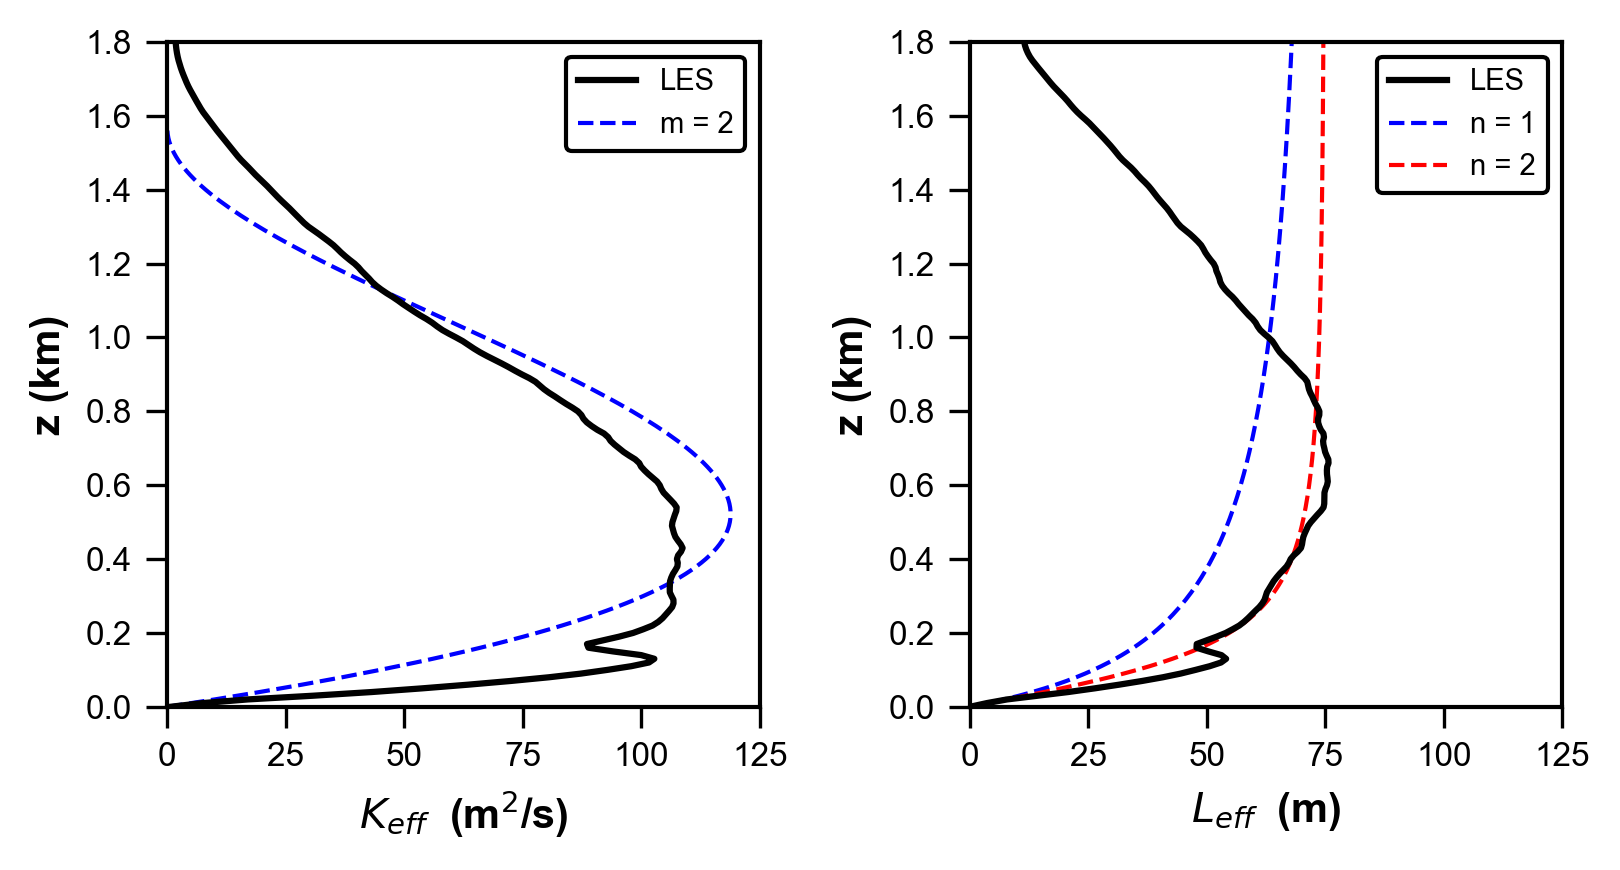

In [13]:
### Vertical diffusivity profile ###

# Read CM1 vertical profiles
les_dir = os.path.join(data_dir, 'CM1/outputs')
prof_data = loadmat(os.path.join(les_dir, 'analysis_profile.mat'))

# Variables & Parameters
ust = prof_data['ust'][0]
zf = prof_data['zf']
h_ref = prof_data['h_pbl'][0]
kappa = 0.4

# Eddy diffusivity model
zf_ = zf[zf <= h_ref]
K_theo1 = 0.6 * 1e3*kappa*ust * zf_ * (1-zf_/h_ref)**2
# K_theo2 = 1e3*kappa*ust * zf_ * (1-zf_/h_ref)**4

# Mixing length model
Linf = 75e-3
L_theo1 = 1e3 * 1 / (1/Linf + 1/(kappa*zf))
L_theo2 = 1e3 * 1 / np.sqrt(1/Linf**2 + 1/(kappa*zf)**2)

# Plot diffusivity & mixing length profiles
fig, axes = plt.subplots(1, 2, figsize=(5.5, 3))
lw = 1.5

axes[0].plot(prof_data['rKeff'] + prof_data['sKeff'], zf, 'k-', lw=lw, label='LES', zorder=10)
axes[0].plot(K_theo1, zf_, 'b--', lw=1, label='m = 2')
# axes[0].plot(K_theo2, zf_, 'r--', lw=1, label='m = 4')
axes[0].set_xlabel('$K_{eff}$  (m$^2$/s)')
axes[0].set_ylabel('z (km)')
axes[0].set_xlim([0, 125])
axes[0].set_ylim([0, 1.8])
axes[0].legend(prop={'size': 7})

axes[1].plot(prof_data['Leff'], zf, 'k-', lw=lw, label='LES', zorder=10)
axes[1].plot(L_theo1, zf, 'b--', lw=1, label='n = 1')
axes[1].plot(L_theo2, zf, 'r--', lw=1, label='n = 2')
axes[1].set_xlabel('$L_{eff}$  (m)')
axes[1].set_ylabel('z (km)')
axes[1].set_xlim([0, 125])
axes[1].set_ylim([0, 1.8])
axes[1].legend(prop={'size': 7}, loc='best')

plt.tight_layout()
# fig.savefig(os.path.join(sup_dir, 'Kl_profile.pdf'), dpi=400, bbox_inches='tight', pad_inches=0)

## Create CM1 input sounding

In [14]:
### Create input sounding ###
# Height levels (m)
z = np.arange(0, 4.1e3, 40)

# Constants
epsilon = 0.622
g = 9.80665     # m/s^2
Rd = 287.04     # J/(kg⋅K)
cp = 1005.7     # J/(kg⋅K)
p_ref = 1e3     # mbar

# Surface values
prs0 = 994.11       # Surface pressure (mbar)
theta0 = 299.65     # Potential temperature (K)
wv0 = 20.1          # Mixing ratio (g/kg)
pi0 = (prs0/p_ref) ** (Rd/cp)   # Nondimensional pressure

### Input sounding: Potential temperature ###
# Transition with piecewise slope
z1, z2 = 0, 700
grad = 0.0058    # Temperature gradient (K/m)
slope = np.piecewise(z, [z<=z1, (z>z1) & (z<z2), z>=z2], [0, lambda t: grad/(z2-z1)*(t-z1), grad])
theta = theta0 + cumulative_trapezoid(slope, z, initial=0)

### Input sounding: Mixing ratio ###
# Transition with piecewise slope
z1, z2 = 500, 1000
grad1, grad2 = -4.2e-3, -2.2e-3     # Mixing ratio gradient ((g/kg)/m)
slope = np.piecewise(z, [z<=z1, (z>z1) & (z<z2), z>=z2], [grad1, lambda t: grad1+(grad2-grad1)/(z2-z1)*(t-z1), grad2])
wv = wv0 + cumulative_trapezoid(slope, z, initial=0)

# Calculate other variables
th_rho = theta * (1 + wv/1e3/epsilon) / (1 + wv/1e3)    # Density potential temp.
dpi_dz = -g / (cp * th_rho)
pi = pi0 + cumulative_trapezoid(dpi_dz, z, initial=0)   # Nondimensional pressure
prs = p_ref * pi ** (cp/Rd)                             # Pressure (mbar)
T = theta * pi - 273.15                                 # Temperature (Celsius)
rh =  wv * prs*1e2 / (wv + epsilon*1e3) / cm1_func.e_sw(T)  # Relative humidity

### Create input sounding file (isnd = 7 or 17) ###

# Ignore wind speed
u, v, wspd = np.zeros(z.shape), np.zeros(z.shape), np.zeros(z.shape)
df_input = pd.DataFrame({'z (m)': z, 'p (mbar)': prs,
                         'theta (K)': theta, 'wv (g/kg)': wv,
                         'u (m/s)': u, 'v (m/s)': v, 'wspd (m/s)': wspd})

# Write input sounding file
# cm1_func.create_sounding(df_input, filename=os.path.join(data_dir, 'CM1/inputs/input_sounding'))